# Final Project: Steam Games Popularity Prediction

https://huggingface.co/datasets/FronkonGames/steam-games-dataset/tree/main

Authors: Autumn Mizer, Steven Thomas, Josiah Reinholz

### Overview

This project determines whether the popularity of Steam games can be predicted using features from the Steam dataset (https://huggingface.co/datasets/FronkonGames/steam-games-dataset/tree/main). The target variable is 'Estimated Owners' treated as the game popularity.

First, statistical analysis was performed using Kruskal-Wallis tests for continuous variables and Chi-Squared tests for categorical, to determine if there are statistically significant differences in the feature distributions across the ownership groups. The main goal with the statistical analysis is to identify which variables are best associated with popularity of a game.

Predictive models were also developed to see how well game popularity can be estimated from the features. Models included are regression approaches like a baseline linear regression model to see linear relationships between the variables, and a random forest regressor to see non linear interactions and also feature dependencies. Also, classification tasks were used, models included are logistic regression and random forest classification to compare performance under a categorical meaning.

### Research Questions

.. more specific but still viable
- What features are best at predicting a games popularity on Steam?
- Do meta critic reviews contribute to a games popularity?
- Does price affect the popularity of a game?
- Can playtime (2 weeks or overtime) suggest the popularity of a game?


### Hypothesis

H0 - There is not a relationship between a games features and its popularity on Steam

HA - There is a relationship between a games features and its popularity on Steam

### Dataset

Brief Summary of Dataset:

The dataset was created by a user named FrokonGames on Hugging Face. The description of why the dataset was created is not included, but we assume it is for regression and classification problems for prediction. The features for each game include things like price, user score, metacritic score, and also general information like the name, description, images used, etc. The target variable we used is 'Estimated Owners' which is classified as categories of user ranges.

In [79]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv('games.csv')

print(df.shape)
df.head()

(122611, 40)


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


# Preprocessing 

In [80]:
# 1. See all unique owner brackets (the names of the classes)
unique_ranges = df['Estimated owners'].unique()
print("Unique Owner Brackets:")
print(unique_ranges)

# 2. See how many unique options there are (the count of classes)
num_options = df['Estimated owners'].nunique()
print(f"\nTotal number of unique categories: {num_options}")

# 3. See the distribution (how many games are in each bracket)
print("\nGames per category:")
print(df['Estimated owners'].value_counts())

# 4. (Optional) Sort them logically to see the progression
print("\nSorted categories:")
print(sorted(df['Estimated owners'].unique()))

Unique Owner Brackets:
['0 - 0' '0 - 20000' '100000 - 200000' '500000 - 1000000' '20000 - 50000'
 '200000 - 500000' '50000 - 100000' '2000000 - 5000000'
 '10000000 - 20000000' '1000000 - 2000000' '20000000 - 50000000'
 '5000000 - 10000000' '100000000 - 200000000' '50000000 - 100000000']

Total number of unique categories: 14

Games per category:
Estimated owners
0 - 20000                75404
0 - 0                    21641
20000 - 50000            11396
50000 - 100000            5355
100000 - 200000           3454
200000 - 500000           2853
500000 - 1000000          1154
1000000 - 2000000          729
2000000 - 5000000          405
5000000 - 10000000         125
10000000 - 20000000         51
20000000 - 50000000         31
50000000 - 100000000         9
100000000 - 200000000        4
Name: count, dtype: int64

Sorted categories:
['0 - 0', '0 - 20000', '100000 - 200000', '1000000 - 2000000', '10000000 - 20000000', '100000000 - 200000000', '20000 - 50000', '200000 - 500000', '2000000

In [81]:
def preprocess_steam_data(df):
    # 1. CLEAN TARGET VARIABLE (Estimated Owners)
    owner_map = {
        "0 - 0": 0,
        "0 - 20000": 1,
        "20000 - 50000": 2,
        "50000 - 100000": 3,
        "100000 - 200000": 4,
        "200000 - 500000": 5,
        "500000 - 1000000": 6,
        "1000000 - 2000000": 7,
        "2000000 - 5000000": 8,
        "5000000 - 10000000": 9,
        "10000000 - 20000000": 10,
        "20000000 - 50000000": 11,
        "50000000 - 100000000": 12,
        "100000000 - 200000000": 13,
    }
    df['target'] = df['Estimated owners'].map(owner_map)
    
    # 2. DATE ENGINEERING
    # Convert 'Aug 1, 2023' format to datetime
    df['Release date'] = pd.to_datetime(df['Release date'], errors='coerce')
    # Calculate days since release (relative to "today" in 2026)
    reference_date = pd.to_datetime('2026-04-30')
    df['Days_Since_Release'] = (reference_date - df['Release date']).dt.days.fillna(0)

    # 3. NUMERIC FEATURES & RATIOS
    # Create a success ratio (Positive reviews vs Total)
    df['Total_Reviews'] = df['Positive'] + df['Negative']
    df['Positive_Ratio'] = df['Positive'] / df['Total_Reviews']
    df['Positive_Ratio'] = df['Positive_Ratio'].fillna(0) # Handle games with 0 reviews
    df['Negative_Ratio'] = df['Negative'] / df['Total_Reviews']
    df['Negative_Ratio'] = df['Negative_Ratio'].fillna(0)
    
    # 4. BINARY ENCODING (True/False to 1/0)
    for col in ['Windows', 'Mac', 'Linux']:
        df[col] = df[col].astype(int)

    # 5. MULTI-LABEL ENCODING (Genres & Tags)
    # These columns are strings like "Action,Adventure,RPG"
    def split_and_clean(x):
        if pd.isna(x) or x == "": return []
        return [i.strip() for i in str(x).split(',')]

    mlb = MultiLabelBinarizer()
    
    # Process Genres
    genre_series = df['Genres'].apply(split_and_clean)
    genre_encoded = mlb.fit_transform(genre_series)
    genre_df = pd.DataFrame(genre_encoded, columns=[f"Genre_{c}" for c in mlb.classes_])
    
    # 6. Convert Text to Length
    df['About_Length'] = df['About the game'].str.len().fillna(0)

    # 7. FINAL ASSEMBLY
    # Drop high-cardinality/text columns that aren't useful for basic classification
    cols_to_drop = [
        'AppID', 'Name', 'Estimated owners', 'Release date', 'About the game', 
        'Supported languages', 'Full audio languages', 'Reviews', 'Header image', 
        'Website', 'Support url', 'Support email', 'Metacritic url', 'Developers', 
        'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies', 'Notes'
    ]
    
    df_final = df.drop(columns=cols_to_drop)
    df_final = pd.concat([df_final, genre_df], axis=1)
    
    return df_final

In [82]:
df_clean = preprocess_steam_data(df)
df_clean.head()

,Peak CCU,Required age,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,...,Genre_Short,Genre_Simulation,Genre_Software Training,Genre_Sports,Genre_Strategy,Genre_Tutorial,Genre_Utilities,Genre_Video Production,Genre_Violent,Genre_Web Publishing
0,0,0,0.00,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,5.24,65,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,4.99,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,8.99,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,4.99,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [83]:
numeric_cols = [
    "Price", "Peak CCU", "Positive_Ratio", "Negative_Ratio", "Days_Since_Release",
    "Metacritic score", "Recommendations", "Average playtime forever",
    "Achievements", "Required age", "About_Length"
]
scaler = StandardScaler()
df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])

df_clean.head()

,Peak CCU,Required age,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,...,Genre_Short,Genre_Simulation,Genre_Software Training,Genre_Sports,Genre_Strategy,Genre_Tutorial,Genre_Utilities,Genre_Video Production,Genre_Violent,Genre_Web Publishing
0,-0.014638,-0.101362,-0.380265,0,0,1,0,0,-0.187763,0,...,0,0,0,0,0,0,0,0,0,0
1,-0.014638,-0.101362,0.037899,65,0,1,0,0,-0.187763,0,...,0,0,0,0,0,0,0,0,0,0
2,-0.014638,-0.101362,0.017948,0,0,1,1,0,-0.187763,0,...,0,0,0,0,0,0,0,0,0,0
3,-0.014370,-0.101362,0.337157,0,1,1,0,0,-0.187763,0,...,0,1,0,0,0,0,0,0,0,0
4,-0.014638,-0.101362,0.017948,0,0,1,0,0,-0.187763,0,...,0,0,0,0,0,0,0,0,0,0


### Statistical Testing

It is helpful to see the distribution od the target variable (estimated owners). A graph is shown below, it can be seen that most of the rows in our dataset falls under 0-20,000 owners. 

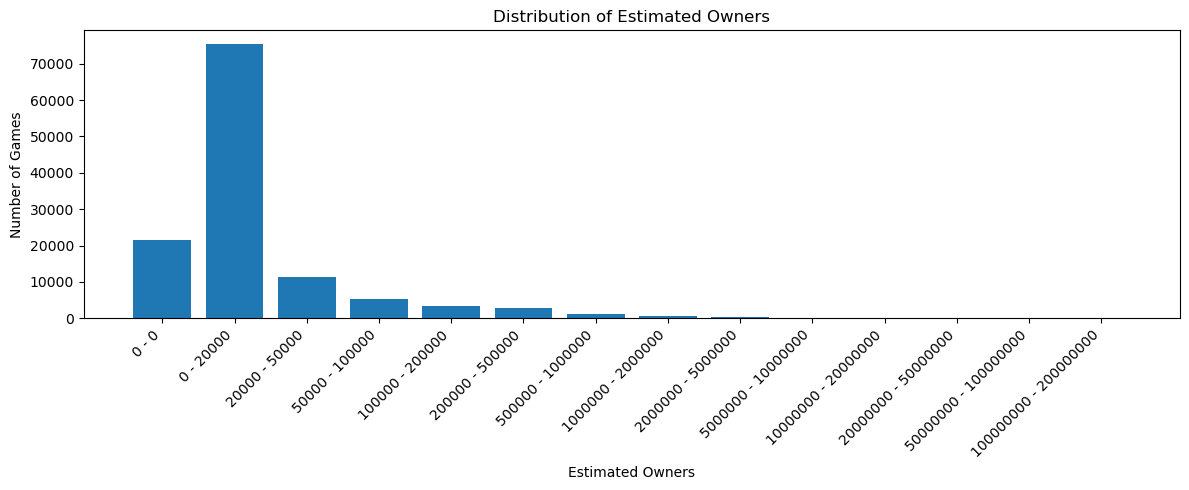

In [84]:
import matplotlib.pyplot as plt

owner_order = [
    "0 - 0", "0 - 20000", "20000 - 50000", "50000 - 100000",
    "100000 - 200000", "200000 - 500000", "500000 - 1000000",
    "1000000 - 2000000", "2000000 - 5000000", "5000000 - 10000000",
    "10000000 - 20000000", "20000000 - 50000000", "50000000 - 100000000",
    "100000000 - 200000000"
]

counts = df["Estimated owners"].value_counts().reindex(owner_order)

plt.figure(figsize=(12, 5))
plt.bar(owner_order, counts)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Estimated Owners")
plt.ylabel("Number of Games")
plt.title("Distribution of Estimated Owners")
plt.tight_layout()
plt.show()

First the Kruskal Wallis Test was used to test 11 numerical variables against the multi category categorical test variable. 

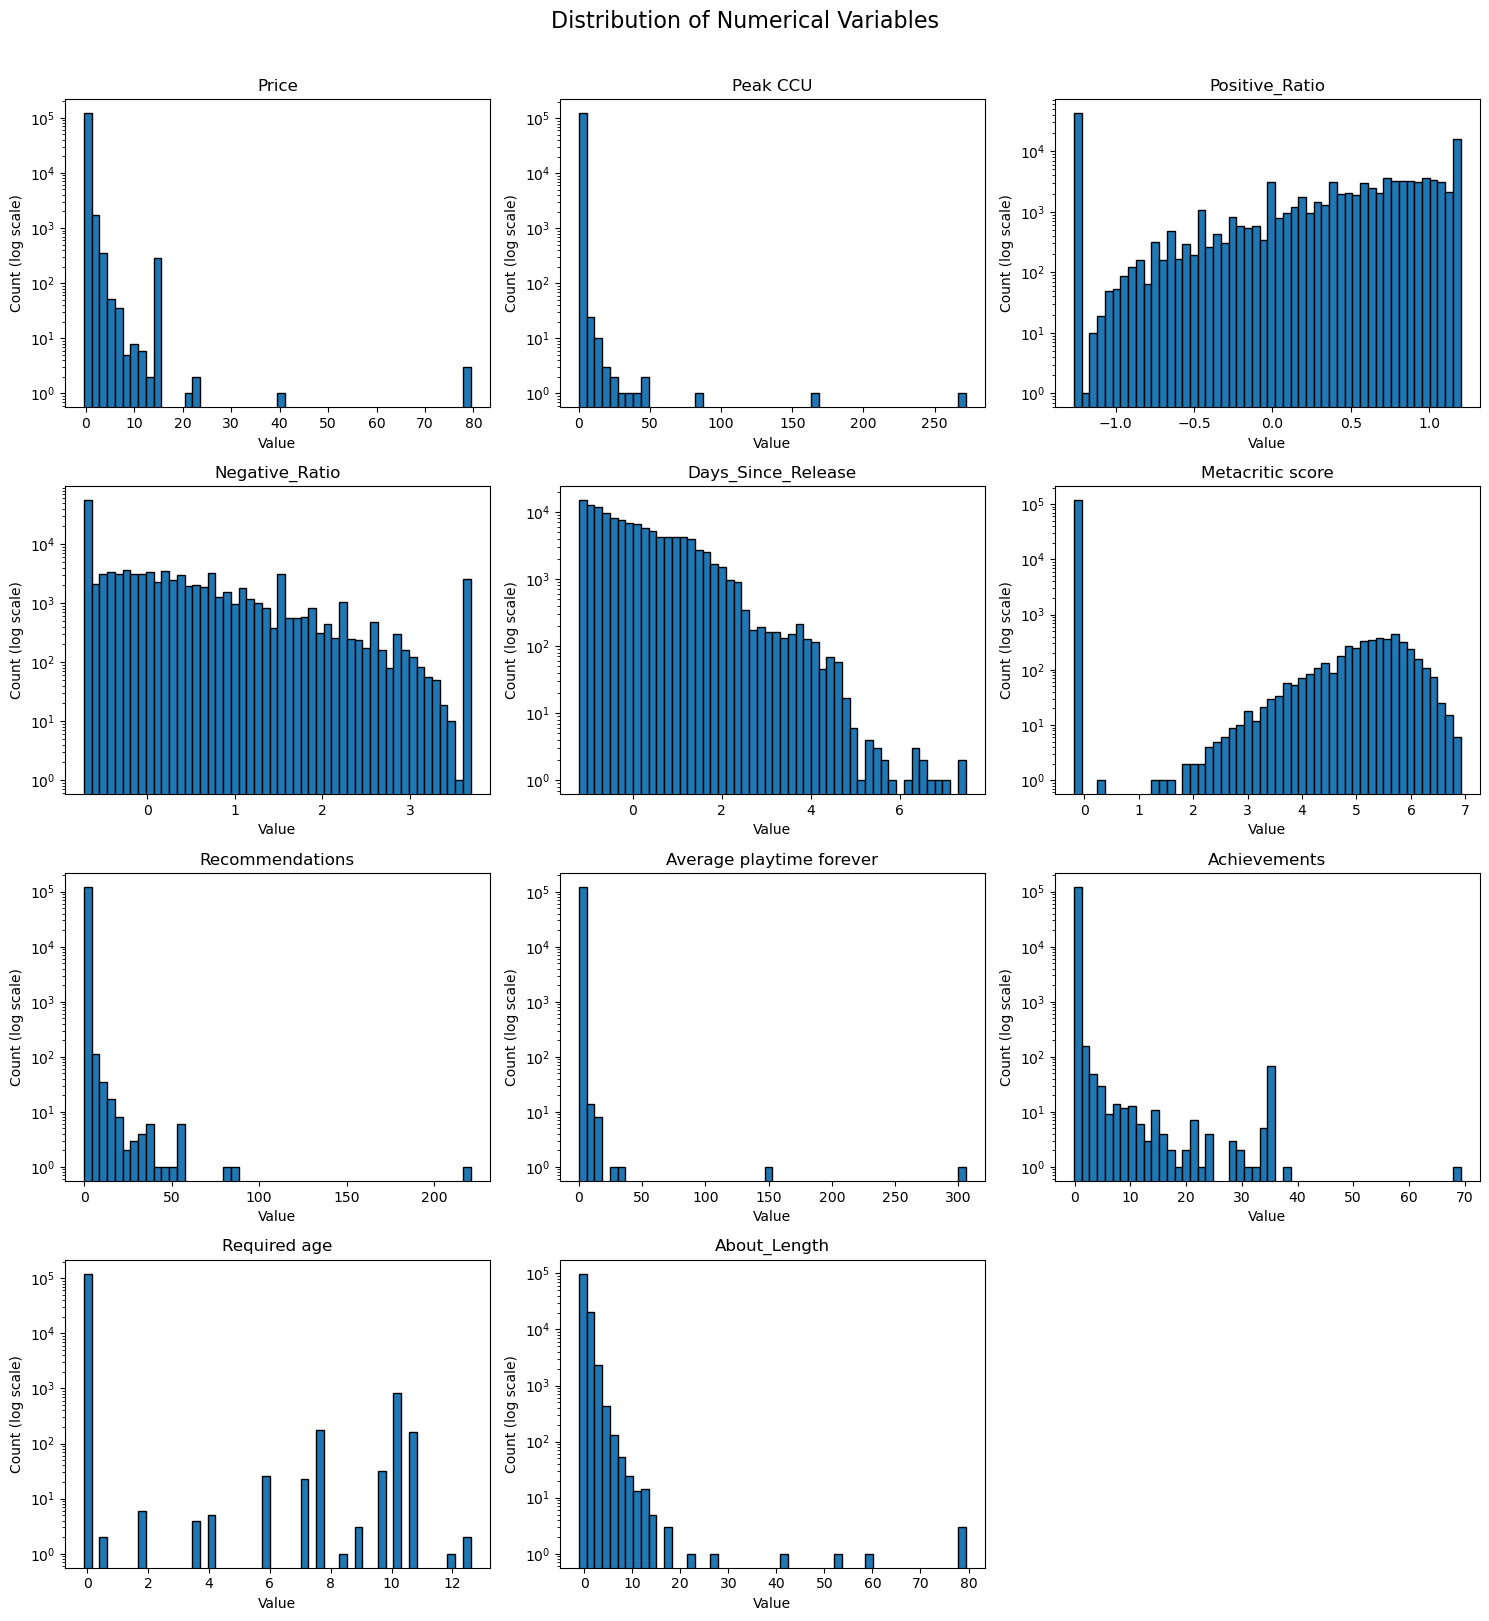

In [85]:
#view histograms of the 11 variables tested
import matplotlib.pyplot as plt
numerical_variables = [
    "Price", "Peak CCU", "Positive_Ratio", "Negative_Ratio", "Days_Since_Release",
    "Metacritic score", "Recommendations", "Average playtime forever",
    "Achievements", "Required age", "About_Length"
]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, var in enumerate(numerical_variables):
    axes[i].hist(df_clean[var].dropna(), bins=50, edgecolor='black')
    axes[i].set_yscale('log')
    axes[i].set_title(var)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count (log scale)')

axes[-1].set_visible(False)

plt.suptitle('Distribution of Numerical Variables', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()



In [86]:
#Perform Kruskal-Wallis test for each numeric variable against the target variable (Estimated Owners)
import numpy as np
from scipy.stats import kruskal
kruskal_results = []

for var in numeric_cols:
    x = df_clean[var].values
    y = df_clean['target'].values

    mask = ~np.isnan(x) & ~np.isnan(y)
    data_x = x[mask]
    data_y = y[mask]

    samples_by_group = []
    for value in set(data_y):
        samples_by_group.append(data_x[data_y == value])

    stat, p = kruskal(*samples_by_group)
    n = len(data_x)
    k = len(set(data_y))
    epsilon_sq = (stat - k + 1) / (n - k)   # epsilon-squared effect size

    kruskal_results.append({
        'variable': var,
        'test': 'Kruskal-Wallis',
        'statistic': stat,
        'p_value': p,
        'epsilon_squared': epsilon_sq
    })

pd.DataFrame(kruskal_results)

,variable,test,statistic,p_value,epsilon_squared
0,Price,Kruskal-Wallis,23605.983484,0.0,0.192443
1,Peak CCU,Kruskal-Wallis,39408.488066,0.0,0.321341
2,Positive_Ratio,Kruskal-Wallis,37980.622700,0.0,0.309695
3,Negative_Ratio,Kruskal-Wallis,31268.053773,0.0,0.254941
4,Days_Since_Release,Kruskal-Wallis,27477.850199,0.0,0.224025
5,Metacritic score,Kruskal-Wallis,25043.051672,0.0,0.204165
6,Recommendations,Kruskal-Wallis,43883.956913,0.0,0.357847
7,Average playtime forever,Kruskal-Wallis,47821.903344,0.0,0.389968
8,Achievements,Kruskal-Wallis,9452.717215,0.0,0.076998
9,Required age,Kruskal-Wallis,9261.869696,0.0,0.075441


The epsilon squared value was added and used. All the variables had extremely low p values, and it does not tell us very much about what variables are significant or show a change in the target variable. The epsilon squared variable measures how much each variable affect the target variable. The formula is ε² = (H − (k−1)) / (n − k), where H is the test statitsitic, k is the number of groups (13 in this case), and n is the number of observations. Average playtime forever, recommendations, and peak CCU had the most effect whiich makes sense! The results can be viewed below. 

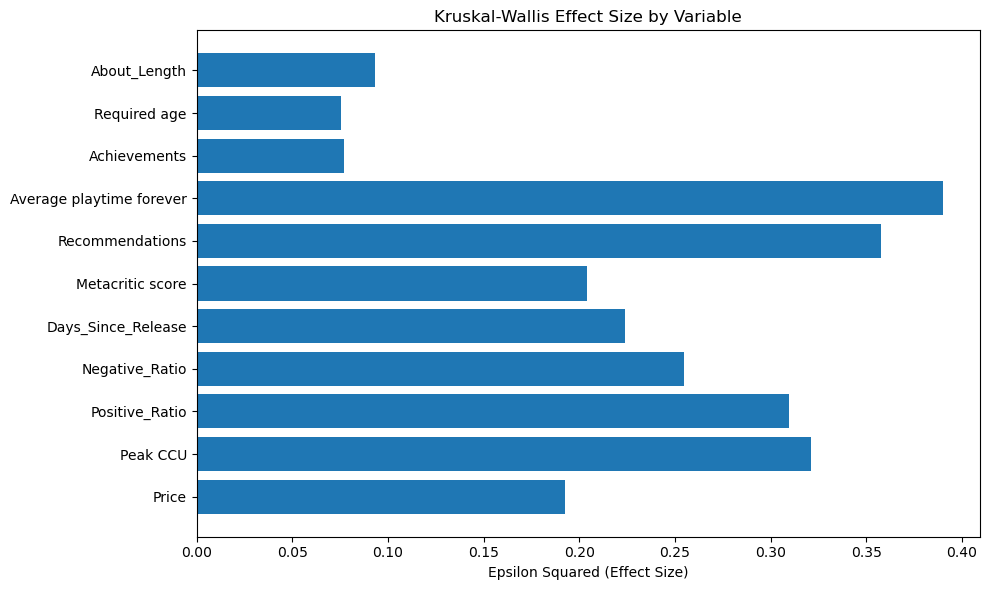

In [87]:
#Visualize the Epsilon Squared values for each variable in a horizontal bar chart
variables = [r['variable'] for r in kruskal_results]
epsilon_values = [r['epsilon_squared'] for r in kruskal_results]

plt.figure(figsize=(10, 6))
bars = plt.barh(variables, epsilon_values)
plt.xlabel('Epsilon Squared (Effect Size)')
plt.title('Kruskal-Wallis Effect Size by Variable')
plt.tight_layout()
plt.show()

Next, the chi squared test was used on the 3 binary platform variable (mac, linux, windows), and on many of the genre words. 

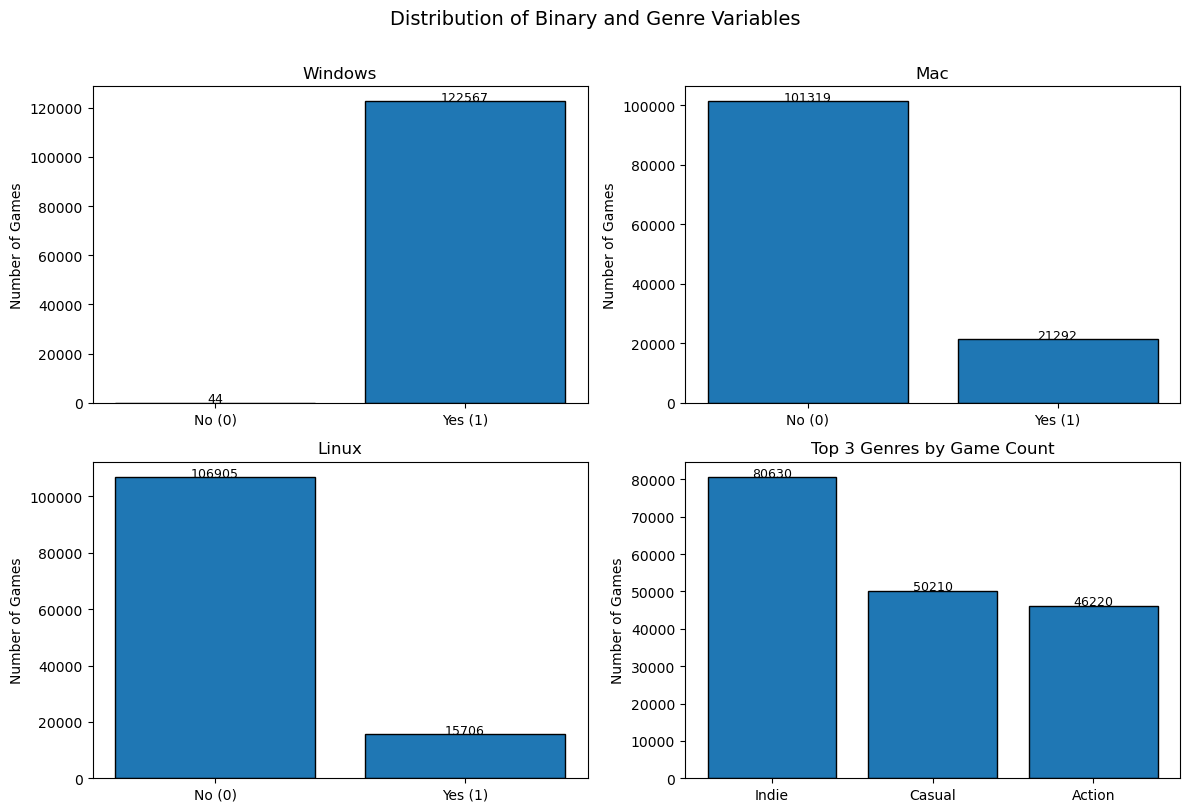

In [88]:
#visualze the binary variables
genre_cols = [col for col in df_clean.columns if col.startswith('Genre_')]
genre_counts = df_clean[genre_cols].sum().sort_values(ascending=False)
top3_genres = genre_counts.head(3)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, var in enumerate(['Windows', 'Mac', 'Linux']):
    counts = df_clean[var].value_counts().sort_index()
    axes[i].bar(['No (0)', 'Yes (1)'], counts.values, edgecolor='black')
    axes[i].set_title(var)
    axes[i].set_ylabel('Number of Games')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 100, str(v), ha='center', fontsize=9)

axes[3].bar(top3_genres.index.str.replace('Genre_', ''), top3_genres.values, edgecolor='black')
axes[3].set_title('Top 3 Genres by Game Count')
axes[3].set_ylabel('Number of Games')
for j, v in enumerate(top3_genres.values):
    axes[3].text(j, v + 100, str(int(v)), ha='center', fontsize=9)

plt.suptitle('Distribution of Binary and Genre Variables', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [89]:
#the results of the chi-squared test can be seen below.
from scipy.stats import chi2_contingency

categorical_variables = ["Windows", "Mac", "Linux"] + [col for col in df_clean.columns if col.startswith("Genre_")]

alpha = 0.05
bonferroni_alpha = alpha / len(categorical_variables)

chi2_results = []

for var in categorical_variables:
    x = df_clean[var].astype(float).values
    y = df_clean["target"].values

    mask = ~np.isnan(x) & ~np.isnan(y)
    data_x = x[mask]
    data_y = y[mask]

    ct = pd.crosstab(data_y, data_x)
    chi2_stat, p, dof, expected = chi2_contingency(ct)

    n = ct.sum().sum()
    min_dim = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2_stat / (n * min_dim))

    chi2_results.append({
        'variable': var,
        'test': 'Chi-Squared',
        'statistic': chi2_stat,
        'p_value': p,
        'significant (Bonferroni)': p < bonferroni_alpha
    })

pd.DataFrame(chi2_results)

,variable,test,statistic,p_value,significant (Bonferroni)
0,Windows,Chi-Squared,4.967473,9.759022e-01,False
1,Mac,Chi-Squared,2806.510131,0.000000e+00,True
2,Linux,Chi-Squared,1401.685027,6.653857e-292,True
3,Genre_360 Video,Chi-Squared,0.626059,9.999998e-01,False
4,Genre_Accounting,Chi-Squared,6.322454,9.336260e-01,False
5,Genre_Action,Chi-Squared,2994.559909,0.000000e+00,True
6,Genre_Adventure,Chi-Squared,2619.962796,0.000000e+00,True
7,Genre_Animation & Modeling,Chi-Squared,31.373303,2.972474e-03,False
8,Genre_Audio Production,Chi-Squared,23.518141,3.586280e-02,False
9,Genre_Casual,Chi-Squared,3245.716227,0.000000e+00,True


These results are interesting. After testing it was found that the Mac and Linux variables were significant, and genres such as adventure, casual, and education were deemed important. 

### Regression

The code segment below handles NaNs by filling with the median of that column, preventing bias from dropping rows. Also, the target variable is defined nad so is the feature set.

In [90]:
# fill NaNs with median
for col in df_clean.columns:
    if df_clean[col].dtype in ['float64', 'int64']:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# target
y = df_clean["target"]

# features
X = df_clean.drop(columns=["target", "Positive", "Negative"])

The code segment below splits the data into training and testing sets with an 80/20 split.

In [91]:
from sklearn.model_selection import train_test_split

# split up into train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The code segment below trains a linear regression model as the baseline, assuming a linear relationship between the target and the features

In [92]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
 
# baseline model
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

# partially linear, model missing complex relationships
print(f"Linear Regression RMSE: {rmse_lr}")
print(f"Linear Regression R^2: {r2_lr}")

Linear Regression RMSE: 0.9721269623969115
Linear Regression R^2: 0.4376220048607885


The code segment below extracts coefficients from the model to see how each feature affects predictions. Positive = increase in popularity, Negative = decrease in popularity

In [93]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr.coef_
}).sort_values(by="coefficient", key=abs, ascending=False)

# unstable coefs due to multicollinearity
print(coef_df)

                        feature  coefficient
39                  Genre_Movie     2.615548
10                   Score rank    -0.796217
13     Average playtime forever     0.623173
33               Genre_Episodic    -0.524462
50               Genre_Tutorial    -0.524462
45                  Genre_Short    -0.524462
30            Genre_Documentary    -0.524462
22              Genre_360 Video    -0.524462
53                Genre_Violent    -0.518800
44         Genre_Sexual Content    -0.475158
38  Genre_Massively Multiplayer     0.387136
54         Genre_Web Publishing     0.386215
0                      Peak CCU    -0.374601
19               Positive_Ratio     0.333667
8              Metacritic score     0.317640
17           Days_Since_Release     0.265106
32              Genre_Education    -0.212823
27       Genre_Audio Production    -0.192018
5                       Windows     0.170796
42                    Genre_RPG     0.152576
34           Genre_Free To Play     0.138803
29  Genre_

The code segment below plots the LR model predicted vs actual for popularity

Text(0.5, 1.0, 'Linear Regression: Predicted vs Actual')

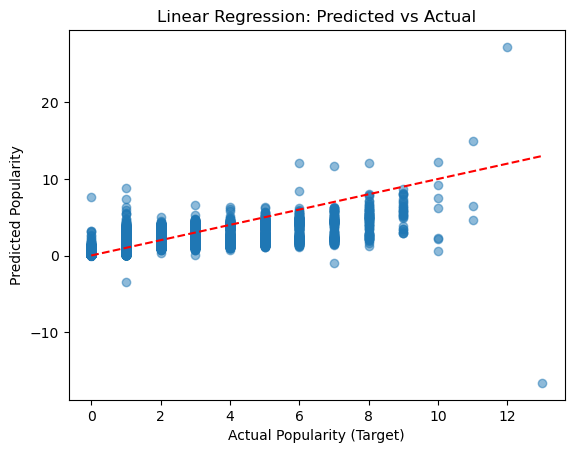

In [94]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Popularity (Target)")
plt.ylabel("Predicted Popularity")
plt.title("Linear Regression: Predicted vs Actual")

The code segment below is a residual analysis vs the actual

Text(0.5, 1.0, 'Residuals vs Actual (Linear Regression)')

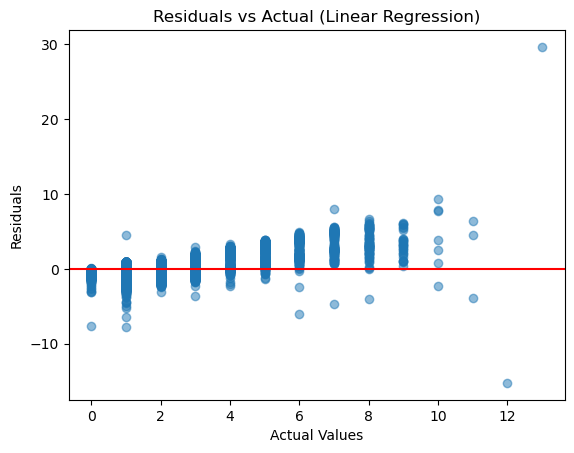

In [95]:
residuals = y_test - y_pred_lr

plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Actual (Linear Regression)")

The code segment below is training of a random forest regressor model to capture non linear relationships and interactions between the features.

In [96]:
from sklearn.ensemble import RandomForestRegressor

# random forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# higher R^2 and lower RMSE than linear regression, captures non-linear relationships
print(f"Random Forest RMSE: {rmse_rf}")
print(f"Random Forest R^2: {r2_rf}")

Random Forest RMSE: 0.5580094573570034
Random Forest R^2: 0.8147042488463895


The code segment below shows the feature importance scores

In [97]:
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_ * 100
}).sort_values(by='importance', ascending=False)

print(feature_importances)

                        feature  importance
18                Total_Reviews   76.590725
17           Days_Since_Release    5.042158
2                         Price    3.999415
21                 About_Length    2.657685
12              Recommendations    1.250037
11                 Achievements    1.197207
19               Positive_Ratio    1.182110
20               Negative_Ratio    1.169936
3                      Discount    0.960235
13     Average playtime forever    0.887932
15      Median playtime forever    0.873700
0                      Peak CCU    0.698374
4                     DLC count    0.339542
25              Genre_Adventure    0.274867
37                  Genre_Indie    0.265437
49               Genre_Strategy    0.264725
24                 Genre_Action    0.264643
28                 Genre_Casual    0.233502
46             Genre_Simulation    0.224436
8              Metacritic score    0.200180
6                           Mac    0.189403
7                         Linux 

Text(0.5, 1.0, 'Top 15 Feature Importances RF')

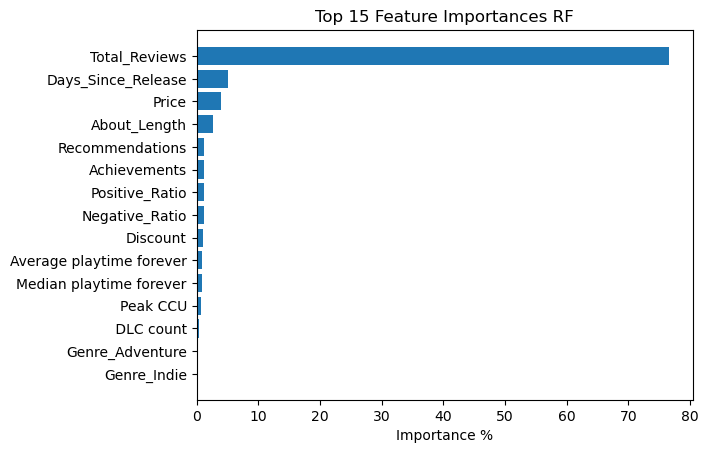

In [98]:
fi = feature_importances.copy()
fi["importance"] = fi["importance"] / fi["importance"].sum() * 100

plt.barh(fi["feature"][:15][::-1], fi["importance"][:15][::-1])
plt.xlabel("Importance %")
plt.title("Top 15 Feature Importances RF")

The code segment below plots the predicted vs actual popularities for the RF model

Text(0.5, 1.0, 'Random Forest: Predicted vs Actual')

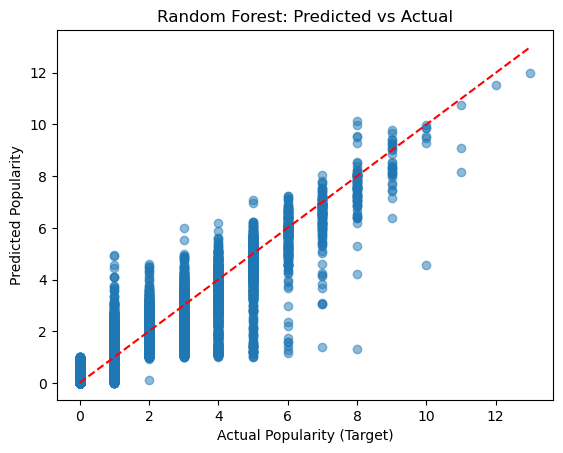

In [99]:
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Popularity (Target)")
plt.ylabel("Predicted Popularity")
plt.title("Random Forest: Predicted vs Actual")

Model comparison of the baseline LR model and the random forest model between the RMSE and R^2

In [100]:
print('Linear Regression vs Random Forest\n')
print('Model: Linear Regression')
print(f'RMSE: {rmse_lr}, R^2: {r2_lr}\n')
print('Model: Random Forest')
print(f'RMSE: {rmse_rf}, R^2: {r2_rf}')

Linear Regression vs Random Forest

Model: Linear Regression
RMSE: 0.9721269623969115, R^2: 0.4376220048607885

Model: Random Forest
RMSE: 0.5580094573570034, R^2: 0.8147042488463895


# Classification

In [101]:
#fill missing values in 'Score rank' with 0
df_clean['Score rank'] = df_clean['Score rank'].fillna(0)

X = df_clean.drop(columns=['target']) 
y = df_clean['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000) 
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.77      0.87      0.82      4304
           1       0.77      0.92      0.84     15138
           2       0.22      0.03      0.05      2292
           3       0.25      0.03      0.06      1077
           4       0.34      0.07      0.11       666
           5       0.49      0.49      0.49       576
           6       0.47      0.23      0.31       212
           7       0.45      0.38      0.41       131
           8       0.54      0.35      0.43        85
           9       0.56      0.30      0.39        30
          10       0.20      0.14      0.17         7
          11       0.33      0.33      0.33         3
          12       0.00      0.00      0.00         1
          13       1.00      1.00      1.00         1

    accuracy                           0.75     24523
   macro avg       0.46      0.37      0.39     24523
weighted avg       0.67      0.75      0.69     24

/opt/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [102]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Define X and y
X = df_clean.drop(columns=['target'])
y = df_clean['target']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 4. Predict and Evaluate
y_pred = rf_model.predict(X_test)

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


Overall Accuracy: 0.80

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      4304
           1       0.85      0.94      0.89     15138
           2       0.45      0.24      0.31      2292
           3       0.38      0.21      0.27      1077
           4       0.40      0.30      0.34       666
           5       0.56      0.56      0.56       576
           6       0.51      0.44      0.47       212
           7       0.49      0.50      0.49       131
           8       0.60      0.41      0.49        85
           9       0.50      0.33      0.40        30
          10       0.25      0.14      0.18         7
          11       0.33      0.33      0.33         3
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         1

    accuracy                           0.80     24523
   macro avg       0.44      0.38      0.40     24523
weighted avg       0.77   

/opt/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

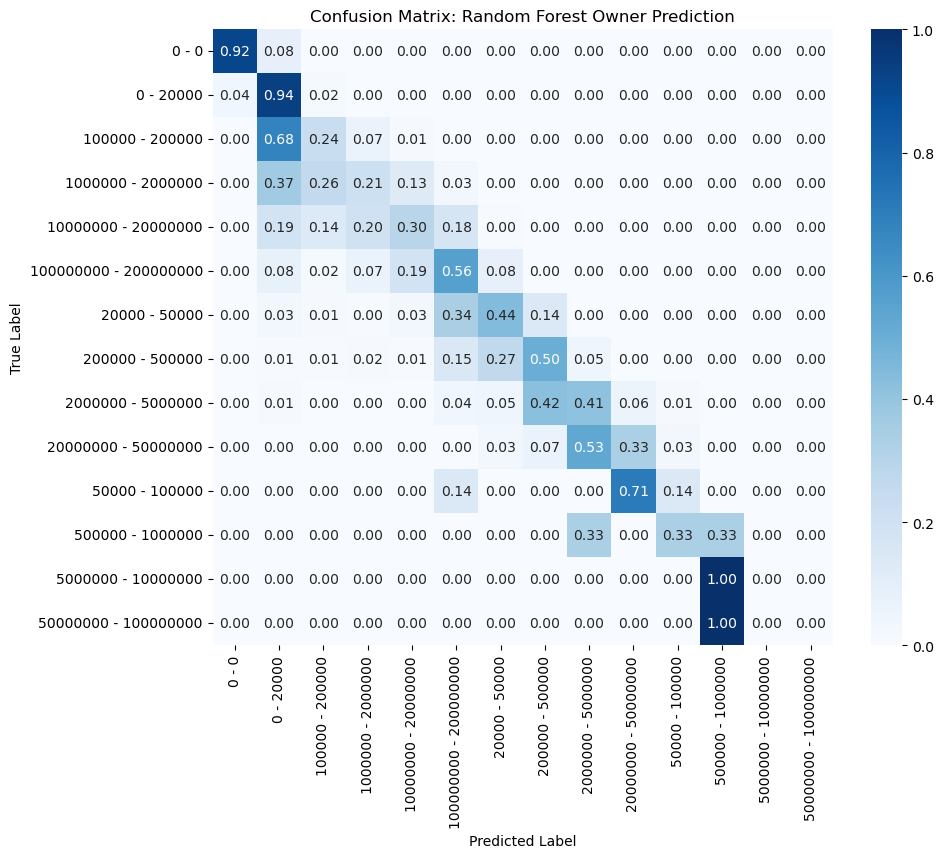

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the confusion matrix data
# y_test are the true labels, y_pred are what the Random Forest guessed
cm = confusion_matrix(y_test, y_pred, normalize='true')

# 2. Get the class names for the axis labels
# This ensures the matrix shows "0-20k" instead of just "1"
class_names = sorted(df['Estimated owners'].unique())

# 3. Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Random Forest Owner Prediction')
plt.show()


### Results

Results Analysis:

Results from the statistical testing and modeling say that there may be a meaningful relationship between steam game features and the game popularity using 'Estimated Owners'. Nearly all the statistical tests produced extremely small p values, so the null can be rejected. For the Kruskal Wallis tests, the numerical variables tested were statistically signigicant with p values close to 0. Epsilon squared sizes was also tested, and variables strongest against popularity are 'Average Playtime Forever' at .39, 'Reccomendations' at .36, and 'Peak CCU' at .32. So, player engagement with a game can be said to have strong correlation on the prediction of game popularity. Also, the chi-squared analysis showed statistically significant categorical variables like mac and linux, and some genres like action, adventure, etc. So, we can conclude that genre selection has some impact on game popularity and also what platforms the. game is on.

For the models, regression (the linear baseline model) showed that some features correlated well with game popularity like some of the genres and 'Average playtime forever' and also the positive ratio. This did not capture the non linear relationships/interactions though, and can be seen with the unstable coefficients and the patterns in the residual plot. For the random forest regressor, it performed better due to being able to see non linear relationships/interactions. The feature important scores showed that mainly total reviews dominated the importance, and also price contributed too but not nearly as much. So again, engagement seemed to be the strongest in finding game popularity. 

For classification, logistic regression achieved 75% accuracy while the random forest classifier achieved about 80%. Both did better in categories where the estimated user category is more common, rather than the higher ones. Low ownership was predicted correctly most times, but with higher popularity both models struggled. Likely due to few examples/class imbalance.

From these results we can assume the alternative hypothesis that there is a relationship between a games features and its popularity on Steam. Some ways this analysis could be improved for future use is using a better balanced dataset, maybe even a dataset with only triple A titles that definitly have lots of user score and metacritic reviews. We assumed metacritic reviews would be one of the higher predicting features but due to the sparsity of it in the dataset for each game there was not enough data to conclude if it does. We could also do feature engineering like seeing details of reviews and game descriptions. A lesson we learned from this project is that the statistical significance doesnt really mean that its important due to the large dataset. This is because the effect size and the feature importance scores showed more than just the p values. Also, we saw that non lienar models like random forest is better for datasets that are from the real world rather than linear, due to variables having complex relationships/interactions.